In [1]:
# Ячейка 1 - Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Библиотеки загружены!")

Библиотеки загружены!


In [2]:
# Ячейка 2 - Загрузка датасета Aruba
df_aruba = pd.read_csv('../../data/aruba/aruba.csv', 
                        header=None, 
                        sep=' ',
                        names=['date', 'time', 'sensor', 'value', 'activity'])

print(f"Размер датасета: {df_aruba.shape}")
print(f"\nПервые 5 строк:")
df_aruba.head()

Размер датасета: (1602821, 5)

Первые 5 строк:


,date,time,sensor,value,activity
0,"2010-11-04,00:03:50.209589,Bedroom,ON",NaN,NaN,NaN,NaN
1,"2010-11-04,00:03:57.399391,Bedroom,OFF",NaN,NaN,NaN,NaN
2,"2010-11-04,02:32:33.351906,Bedroom,ON",NaN,NaN,NaN,NaN
3,"2010-11-04,02:32:38.895958,Bedroom,OFF",NaN,NaN,NaN,NaN
4,"2010-11-04,03:42:21.82365,Bedroom,ON",NaN,NaN,NaN,NaN


In [3]:
# Ячейка 3 - Правильная загрузка
df_aruba = pd.read_csv('../../data/aruba/aruba.csv', 
                        header=None,
                        sep='\t',
                        names=['date', 'time', 'sensor', 'value', 'activity'])

# Если не сработает, попробуем посмотреть сырые данные
print("Первые 3 строки сырых данных:")
with open('../../data/aruba/aruba.csv', 'r') as f:
    for i, line in enumerate(f):
        if i < 3:
            print(repr(line))

Первые 3 строки сырых данных:
'2010-11-04,00:03:50.209589,Bedroom,ON\n'
'2010-11-04,00:03:57.399391,Bedroom,OFF\n'
'2010-11-04,02:32:33.351906,Bedroom,ON\n'


In [4]:
# Ячейка 4 - Правильная загрузка с запятой
df_aruba = pd.read_csv('../../data/aruba/aruba.csv', 
                        header=None,
                        sep=',',
                        names=['date', 'time', 'sensor', 'value', 'activity'])

print(f"Размер: {df_aruba.shape}")
print(f"\nСтолбцы: {df_aruba.columns.tolist()}")
print(f"\nПервые 5 строк:")
df_aruba.head()

Размер: (1602821, 5)

Столбцы: ['date', 'time', 'sensor', 'value', 'activity']

Первые 5 строк:


,date,time,sensor,value,activity
0,2010-11-04,00:03:50.209589,Bedroom,ON,NaN
1,2010-11-04,00:03:57.399391,Bedroom,OFF,NaN
2,2010-11-04,02:32:33.351906,Bedroom,ON,NaN
3,2010-11-04,02:32:38.895958,Bedroom,OFF,NaN
4,2010-11-04,03:42:21.82365,Bedroom,ON,NaN


In [5]:
# Ячейка 5 - Анализ активностей
print("Уникальные активности:")
print(df_aruba['activity'].value_counts())

print(f"\nУникальных сенсоров: {df_aruba['sensor'].nunique()}")
print("\nСписок сенсоров:")
print(df_aruba['sensor'].unique())

Уникальные активности:
Series([], Name: count, dtype: int64)

Уникальных сенсоров: 10

Список сенсоров:
['Bedroom' 'Bathroom' 'OtherRoom' 'LivingRoom' 'LoungeChair' 'OutsideDoor'
 'DiningRoom' 'Kitchen' 'GuestRoom' 'WorkArea']


In [6]:
# Ячейка 6 - Посмотрим строки с активностями
df_activities = df_aruba.dropna(subset=['activity'])
print(f"Строк с активностями: {len(df_activities)}")
print(f"\nУникальные активности:")
print(df_activities['activity'].value_counts())

Строк с активностями: 0

Уникальные активности:
Series([], Name: count, dtype: int64)


In [7]:
# Ячейка 7 - Смотрим сырой файл подробнее
with open('../../data/aruba/aruba.csv', 'r') as f:
    lines = f.readlines()

print("Первые 10 строк:")
for line in lines[:10]:
    print(repr(line))

print("\nСтроки где есть активность (ищем не ON/OFF):")
for line in lines[:500]:
    parts = line.strip().split(',')
    if len(parts) > 3 and parts[3] not in ['ON', 'OFF']:
        print(repr(line))
        break

Первые 10 строк:
'2010-11-04,00:03:50.209589,Bedroom,ON\n'
'2010-11-04,00:03:57.399391,Bedroom,OFF\n'
'2010-11-04,02:32:33.351906,Bedroom,ON\n'
'2010-11-04,02:32:38.895958,Bedroom,OFF\n'
'2010-11-04,03:42:21.82365,Bedroom,ON\n'
'2010-11-04,03:42:25.93973,Bedroom,OFF\n'
'2010-11-04,03:49:52.412755,Bedroom,ON\n'
'2010-11-04,03:49:57.473649,Bedroom,OFF\n'
'2010-11-04,04:14:32.835757,Bedroom,ON\n'
'2010-11-04,04:14:33.203704,Bedroom,ON\n'

Строки где есть активность (ищем не ON/OFF):


In [8]:
# Ячейка 8 - Правильная загрузка (4 колонки)
df_aruba = pd.read_csv('../../data/aruba/aruba.csv', 
                        header=None,
                        sep=',',
                        names=['date', 'time', 'sensor', 'value'])

# Объединяем дату и время
df_aruba['datetime'] = pd.to_datetime(df_aruba['date'] + ' ' + df_aruba['time'])
df_aruba['hour'] = df_aruba['datetime'].dt.hour
df_aruba['weekday'] = df_aruba['datetime'].dt.day_name()

print(f"Размер: {df_aruba.shape}")
print(f"\nПервые 5 строк:")
print(df_aruba.head())

print(f"\nПериод данных:")
print(f"От: {df_aruba['datetime'].min()}")
print(f"До: {df_aruba['datetime'].max()}")

ValueError: time data "2011-01-29 09:22:15" doesn't match format "%Y-%m-%d %H:%M:%S.%f", at position 626196. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [9]:
# Ячейка 9 - Загрузка с обработкой ошибок дат
df_aruba = pd.read_csv('../../data/aruba/aruba.csv', 
                        header=None,
                        sep=',',
                        names=['date', 'time', 'sensor', 'value'])

# Используем format='mixed' для разных форматов времени
df_aruba['datetime'] = pd.to_datetime(
    df_aruba['date'] + ' ' + df_aruba['time'], 
    format='mixed',
    errors='coerce'
)

df_aruba['hour'] = df_aruba['datetime'].dt.hour
df_aruba['weekday'] = df_aruba['datetime'].dt.day_name()

print(f"Размер: {df_aruba.shape}")
print(f"Пустых дат: {df_aruba['datetime'].isna().sum()}")
print(f"\

SyntaxError: unterminated f-string literal (detected at line 19) (2254454230.py, line 19)

In [10]:
# Ячейка 9 - Загрузка с обработкой ошибок дат
df_aruba = pd.read_csv('../../data/aruba/aruba.csv', 
                        header=None,
                        sep=',',
                        names=['date', 'time', 'sensor', 'value'])

df_aruba['datetime'] = pd.to_datetime(
    df_aruba['date'] + ' ' + df_aruba['time'], 
    format='mixed',
    errors='coerce'
)

df_aruba['hour'] = df_aruba['datetime'].dt.hour
df_aruba['weekday'] = df_aruba['datetime'].dt.day_name()

print(f"Размер: {df_aruba.shape}")
print(f"Пустых дат: {df_aruba['datetime'].isna().sum()}")
print(f"Первые 5 строк:")
print(df_aruba.head())
print(f"Период: {df_aruba['datetime'].min()} до {df_aruba['datetime'].max()}")

Размер: (1602821, 7)
Пустых дат: 0
Первые 5 строк:
         date             time   sensor value                   datetime  \
0  2010-11-04  00:03:50.209589  Bedroom    ON 2010-11-04 00:03:50.209589   
1  2010-11-04  00:03:57.399391  Bedroom   OFF 2010-11-04 00:03:57.399391   
2  2010-11-04  02:32:33.351906  Bedroom    ON 2010-11-04 02:32:33.351906   
3  2010-11-04  02:32:38.895958  Bedroom   OFF 2010-11-04 02:32:38.895958   
4  2010-11-04   03:42:21.82365  Bedroom    ON 2010-11-04 03:42:21.823650   

   hour   weekday  
0     0  Thursday  
1     0  Thursday  
2     2  Thursday  
3     2  Thursday  
4     3  Thursday  
Период: 2010-11-04 00:03:50.209589 до 2011-06-11 23:20:35.722380


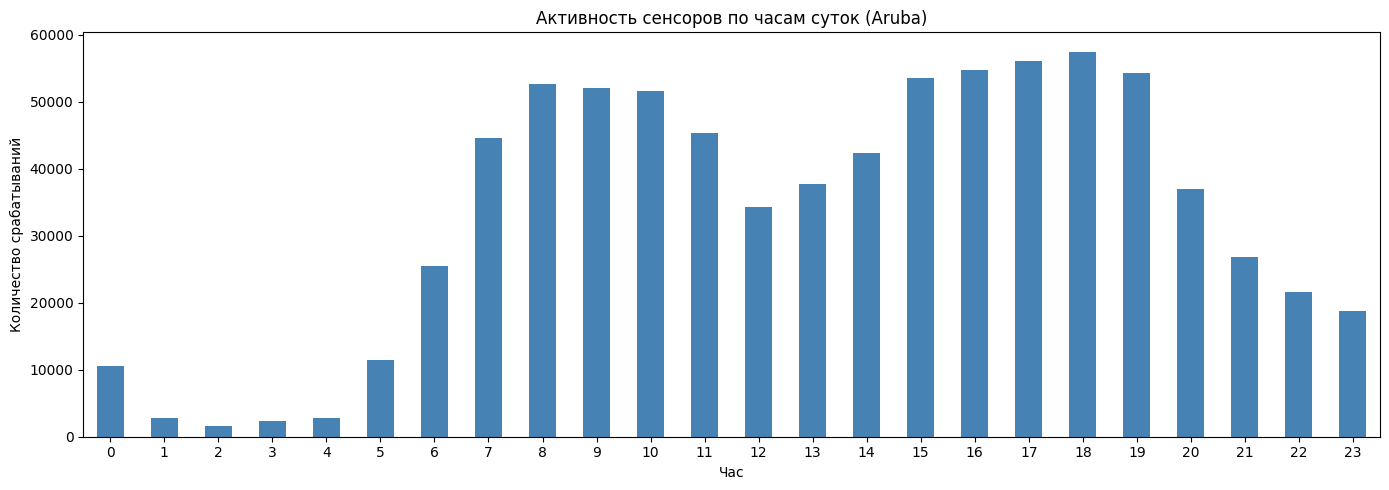

In [11]:
# Ячейка 10 - Визуализация активности по часам
plt.figure(figsize=(14, 5))
df_aruba[df_aruba['value'] == 'ON']['hour'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Активность сенсоров по часам суток (Aruba)')
plt.xlabel('Час')
plt.ylabel('Количество срабатываний')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

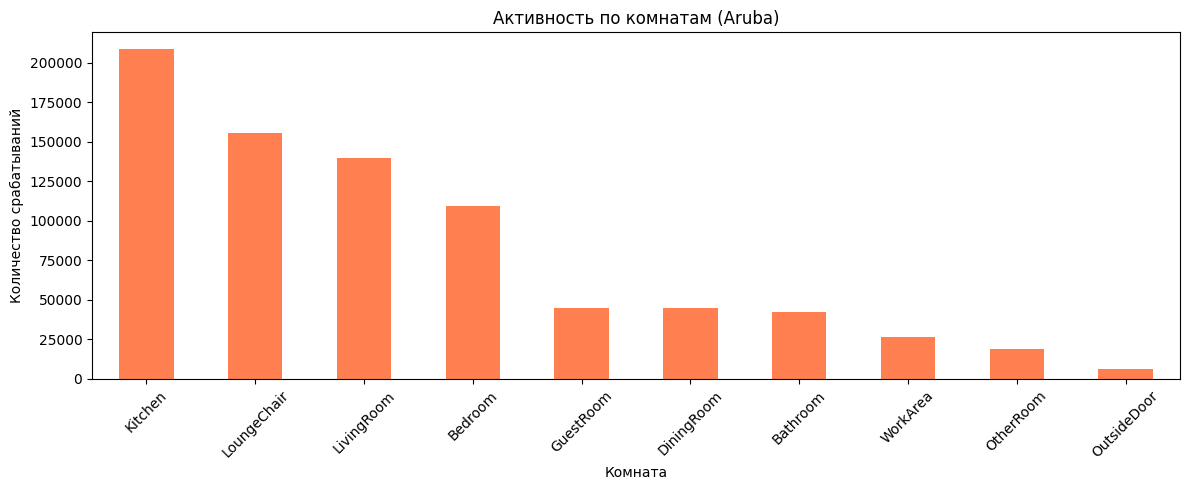

In [12]:
# Ячейка 11 - Активность по сенсорам/комнатам
plt.figure(figsize=(12, 5))
df_aruba[df_aruba['value'] == 'ON']['sensor'].value_counts().plot(kind='bar', color='coral')
plt.title('Активность по комнатам (Aruba)')
plt.xlabel('Комната')
plt.ylabel('Количество срабатываний')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

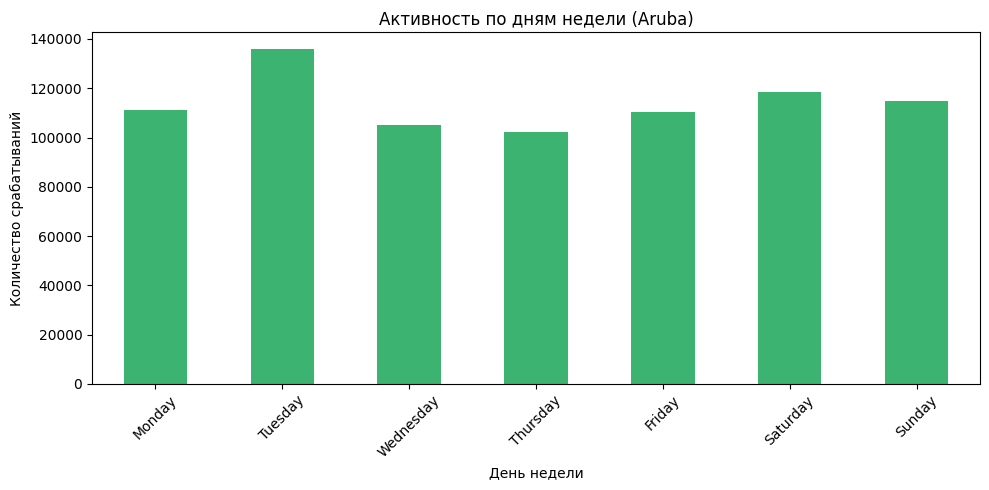

In [13]:
# Ячейка 12 - Активность по дням недели
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
df_aruba[df_aruba['value'] == 'ON']['weekday'].value_counts().reindex(days_order).plot(kind='bar', color='mediumseagreen')
plt.title('Активность по дням недели (Aruba)')
plt.xlabel('День недели')
plt.ylabel('Количество срабатываний')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()